# Dengue Analysis in Guatemala

## Introduction
This notebook analyzes reported dengue cases in Guatemala from 2012 to 2024. The dataset contains information aggregated by year, municipality, and department. The data were obtained from the Ministerio de Salud Pública y Asistencia Social (MSPAS), Guatemala's national public health authority. The objective of this analysis is to explore temporal trends and the geographic distribution of dengue cases across the country.

## Import Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt 

## Load Data

In [10]:
municipality = pd.read_csv('../exports/dengue_municipality.csv')
year_municipality = pd.read_csv('../exports/dengue_year_municipality.csv')
year_totals = pd.read_csv('../exports/dengue_year_totals.csv')


## Data Inspection

In [11]:
municipality.head()

,municipality,department,total_cases
0,COATEPEQUE,QUETZALTENANGO,22599
1,GUATEMALA,GUATEMALA,20709
2,MIXCO,GUATEMALA,16607
3,JUTIAPA,JUTIAPA,15519
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088


In [12]:
municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   municipality  325 non-null    str  
 1   department    325 non-null    str  
 2   total_cases   325 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.7 KB


In [13]:
municipality.describe()

,total_cases
count,325.000000
mean,1122.092308
std,2515.694928
min,1.000000
25%,56.000000
50%,404.000000
75%,1083.000000
max,22599.000000


The data inspection describes that there are 325 municipalities in Guatemala. The mean far exceeds the median, by which it can be inferred that a small number of municipalities account for the burden of the total cases of dengue. The single municipality with the highest cases accounts for 22,599 cases. The data has no missing values.

## Annual Trend Analysis 2012-2024

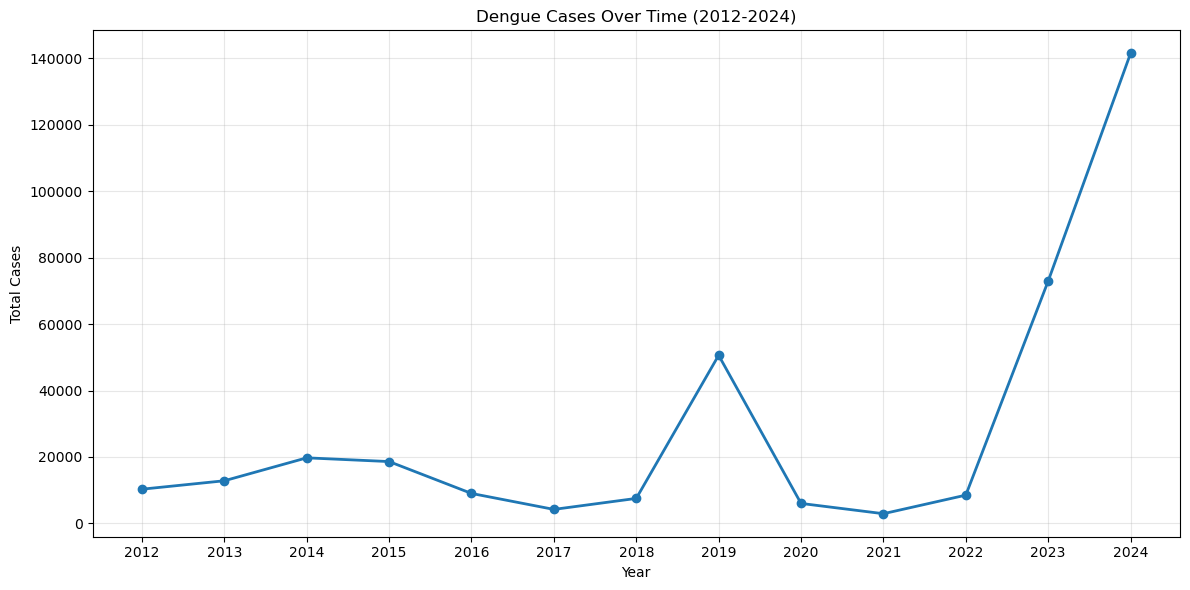

In [14]:
cases_year = year_totals.sort_values('year')
plt.figure(figsize=(12, 6))
plt.plot(cases_year['year'], cases_year['total_cases'], marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.title('Dengue Cases Over Time (2012-2024)')
plt.xticks(cases_year['year'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
From 2012 to 2022, reported dengue cases remained below 20,000 cases per year, except for 2019, when cases increased sharply to more than 40,000. A much larger increase appears in 2023 and 2024, with 2024 reaching the highest value in the period. This large spike affects the scale of the graph and makes earlier yearly variation harder to see. For this reason, a second graph excluding 2023 and 2024 can help examine the pre-spike pattern more clearly.

## Annual Trend Before 2023

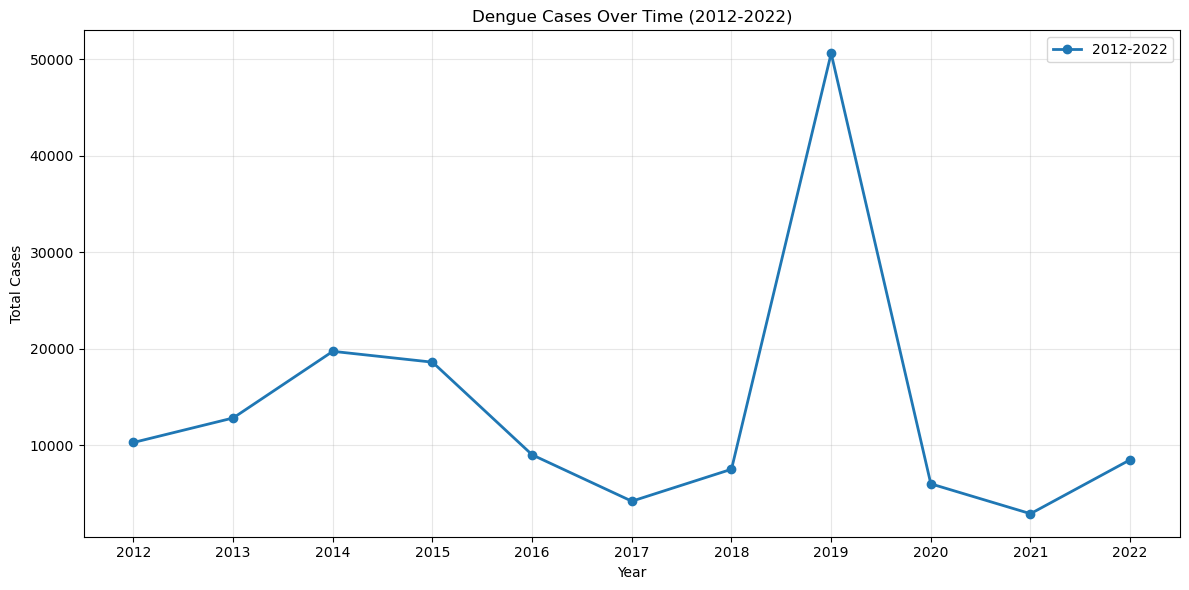

In [15]:
trend_before_2023 = year_totals[year_totals['year'] < 2023]
plt.figure(figsize=(12, 6))
plt.plot(trend_before_2023['year'], trend_before_2023['total_cases'], marker='o', linewidth=2, label='2012-2022')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.title('Dengue Cases Over Time (2012-2022)')
plt.xticks(trend_before_2023['year'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
In 2019, there was a relatively large spike of dengue cases compared to the years prior. From 2012 to 2014, a rise of cases is observed. After that, there was a progressive decline with its lowest number in 2017 followed by a slight increase before the 2019 spike. After 2019, a rapid decrease followed with the number of dengue cases returning to levels prior to 2019 below 20000 cases.

## Distribution of Cases by Municipality

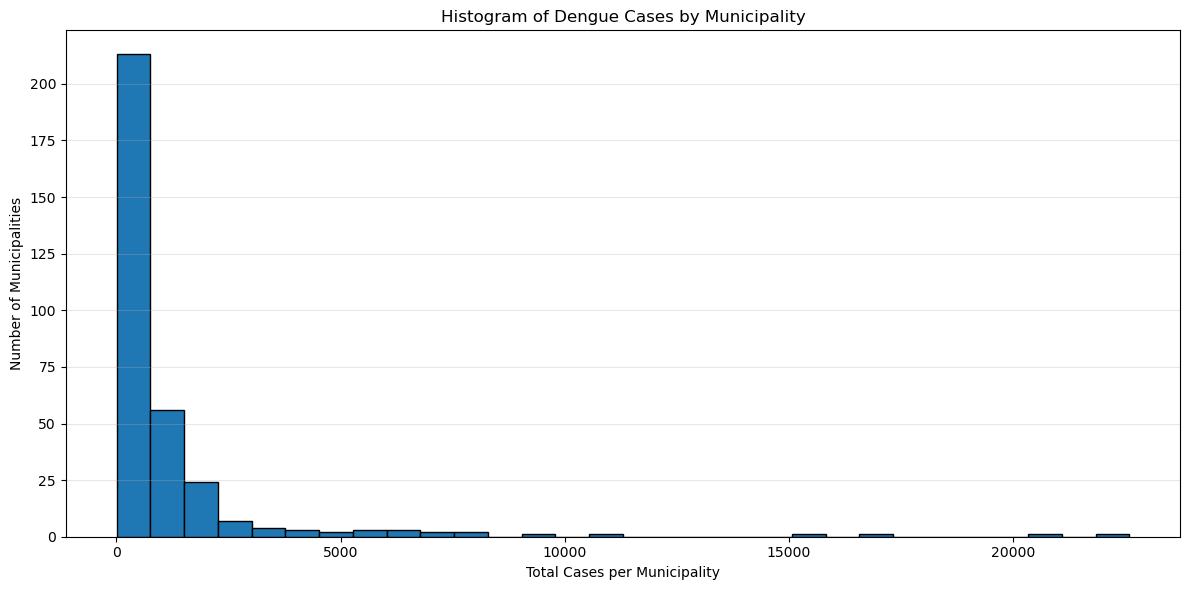

In [16]:
plt.figure(figsize=(12, 6))
plt.hist(municipality['total_cases'], bins=30, edgecolor='black')
plt.xlabel('Total Cases per Municipality')
plt.ylabel('Number of Municipalities')
plt.title('Histogram of Dengue Cases by Municipality')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This histogram shows a strongly right-skewed distribution of dengue cases across municipalities. Most municipalities accumulated relatively low numbers of cases during the study period, while a small number reported substantially higher totals. This pattern is consistent with the descriptive statistics, where the mean number of cases (1,122) exceeds the median (404), suggesting that a few municipalities with very high case counts pull the average upward.


## Top 10 Municipalities by Accumulated Cases (2012-2024)

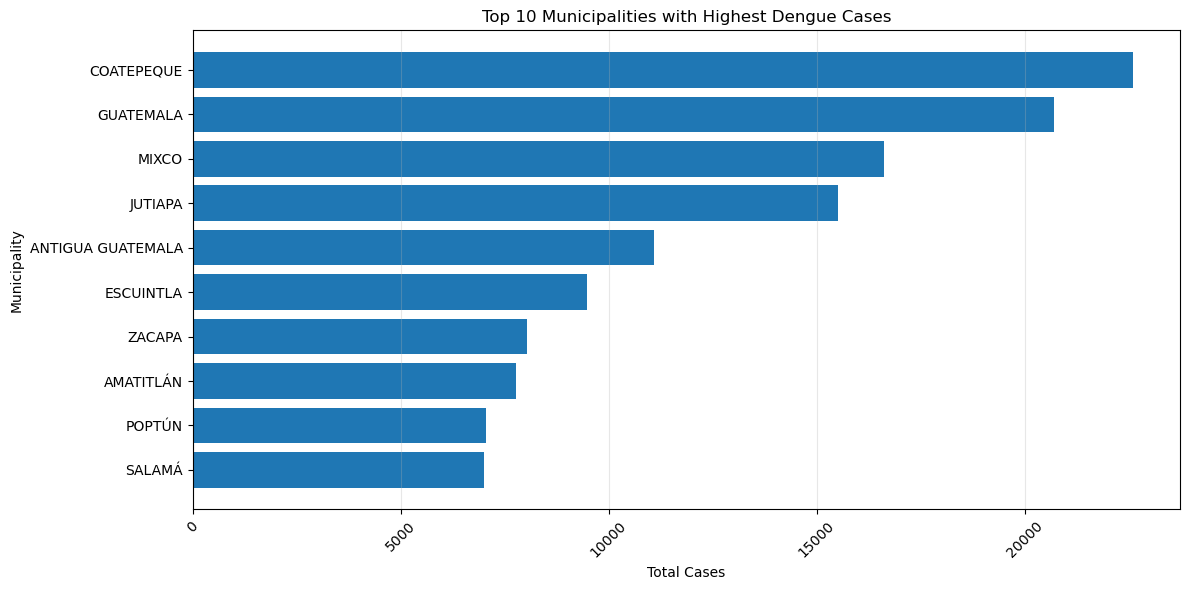

In [17]:
top_municipalities = municipality.groupby('municipality')['total_cases'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_municipalities.index, top_municipalities.values)
plt.xlabel('Total Cases')
plt.ylabel('Municipality')
plt.title('Top 10 Municipalities with Highest Dengue Cases')
plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()  # Invert y-axis to have the highest cases on top
plt.tight_layout()
plt.show()

### Interpretation
The gradual decrease in dengue cases among the top 10 municipalities suggests that several municipalities contribute substantially to the national dengue burden, rather than the burden being concentrated in one or only a few municipalities.

## Persistent and Peak Dengue Burden by Municipality (2012–2024)

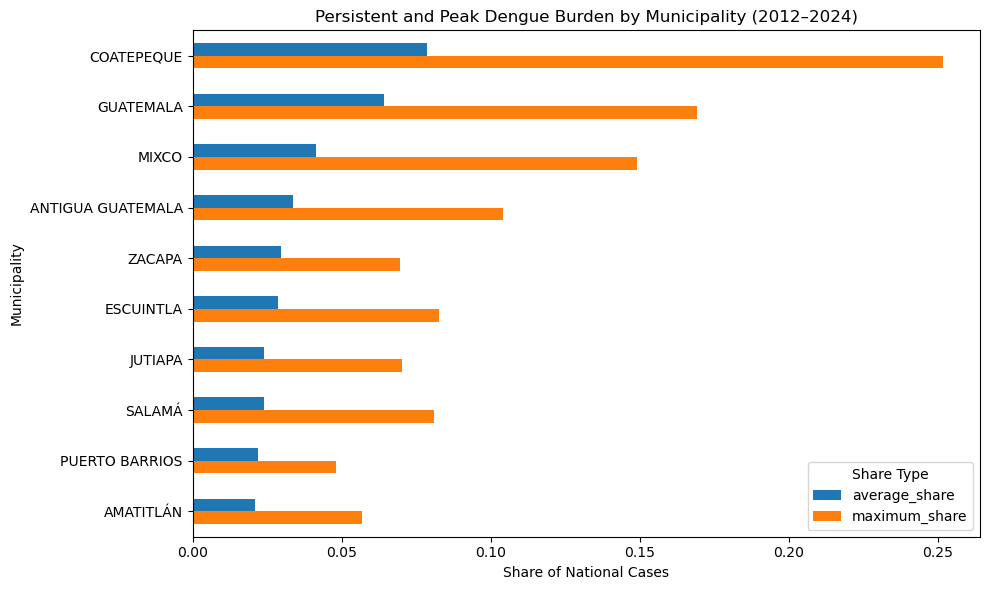

In [18]:
year_municipality_renamed = year_municipality.rename(
    columns={"total_cases": "municipality_cases"}
)
year_totals_renamed = year_totals.rename(
    columns={"total_cases": "national_cases"}
)
municipality_national_cases = pd.merge(year_municipality_renamed, year_totals_renamed, on="year")
municipality_national_cases['municipality_share'] = municipality_national_cases['municipality_cases'] / municipality_national_cases['national_cases']
persistent_driven_burden = municipality_national_cases.groupby("municipality")["municipality_share"].agg(
    average_share="mean",
    maximum_share="max"
).reset_index()
municipality_top10_persistent_burden = persistent_driven_burden.sort_values("average_share", ascending=False).head(10)
municipality_top10_persistent_burden.plot(
    x="municipality",
    y=["average_share", "maximum_share"],
    kind="barh",
    figsize=(10, 6)
)
plt.title("Persistent and Peak Dengue Burden by Municipality (2012–2024)")
plt.xlabel("Share of National Cases")
plt.ylabel("Municipality")
plt.legend(title="Share Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation
The maximum share is higher than the average share for all top municipalities, suggesting that dengue burden fluctuates substantially over time. However, municipalities such as Coatepeque and Guatemala also maintain relatively high average shares, indicating persistent contribution in addition to outbreak-year peaks.

## Conclusions
1. Dengue cases stayed relatively low throughout 2012 to 2022, with one major spike in 2019 and one extreme outbreak period in 2023-2024.
2. Dengue cases are unevenly distributed across municipalities, with a relatively small subset accounting for a disproportionately large share of reported cases.
3. The top 10 municipalities show that several municipalities contribute to the high number of dengue cases throughout 2012-2024. The bars decreased gradually rather than dropping sharply.
4. Dengue cases fluctuate over time, with top municipalities having persistent contribution and peak-year fluctuations, and a few contributing substantially to the average burden.